# London Underground crowding EDA

This notebook explores how crowding varies across London Underground stations, lines, and time of day, using the cleaned local TfL dataset.

## Data sources
- **Station master** (mapping): `data/tube_crowding/stations_master.csv` — 272 station NaPTANs with name, tube lines, lat/lon and a crowding-availability flag
- **Station/line crowding**: `data/tube_crowding/station_line_crowding.csv` — typical passenger flow per station, line and 15-minute time slice

Crowding values are TfL's typical passenger-flow figures per 15-minute slice (from `StopPoint/{id}/Crowding/{line}`), restricted to the 11 Underground lines.

## Data provenance & attribution
- **Source**: Transport for London (TfL) Unified API — <https://api.tfl.gov.uk>
  - Station catalogue: `GET /StopPoint/Mode/tube` and `GET /StopPoint/{id}`
  - Crowding (passenger flow): `GET /StopPoint/{id}/Crowding/{line}?direction=all`
  - Station-level relative crowding: `GET /crowding/{naptan}`
- **Station name cross-check**: [List of London Underground stations, Wikipedia](https://en.wikipedia.org/wiki/List_of_London_Underground_stations) (CC BY-SA).
- **Retrieved**: 2026-09-11.
- **Licence**: Powered by TfL Open Data. Contains OS data © Crown copyright and database rights 2016 and Geomni UK Map data © and database rights 2019. Data is used under the [TfL Open Data terms](https://tfl.gov.uk/info-for/open-data-users/open-data-policy).


In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Resolve the data folder whether the notebook runs from the repo root or its own dir
def find_data_dir():
    for base in (Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent):
        candidate = base / "data" / "tube_crowding"
        if (candidate / "stations_master.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/tube_crowding")

data_dir = find_data_dir()
stations = pd.read_csv(data_dir / "stations_master.csv")
crowding = pd.read_csv(data_dir / "station_line_crowding.csv")

print("stations:", stations.shape, "| crowding:", crowding.shape)
crowding.head()


stations: (272, 9) | crowding: (31752, 5)


,station_naptan,common_name,line,time_slice,value
0,940GZZLUACT,Acton Town Underground Station,district,0000-0015,2
1,940GZZLUACT,Acton Town Underground Station,district,0015-0030,2
2,940GZZLUACT,Acton Town Underground Station,district,0030-0045,0
3,940GZZLUACT,Acton Town Underground Station,district,0045-0100,0
4,940GZZLUACT,Acton Town Underground Station,district,0100-0115,0


In [2]:
# Coverage overview
print("unique stations:", crowding["station_naptan"].nunique())
print("lines:", sorted(crowding["line"].unique()))
print("stations with crowding flag:", int(stations["crowding_available"].sum()), "/", len(stations))
crowding["value"].describe()


unique stations: 267
lines: ['bakerloo', 'central', 'circle', 'district', 'hammersmith-city', 'jubilee', 'metropolitan', 'northern', 'piccadilly', 'victoria', 'waterloo-city']
stations with crowding flag: 270 / 272


count    31752.000000
mean        56.375882
std        118.865997
min          0.000000
25%          2.000000
50%         15.000000
75%         58.000000
max       3189.000000
Name: value, dtype: float64

In [3]:
# time_slice is a 15-min range like "0000-0015"; derive the slice-start clock time
slice_start = crowding["time_slice"].astype(str).str.split("-").str[0]
crowding["minutes"] = slice_start.str[:2].astype(int) * 60 + slice_start.str[2:].astype(int)
crowding["hour"] = crowding["minutes"] // 60
crowding["slice_start"] = slice_start.str[:2] + ":" + slice_start.str[2:]

# average flow per line
crowding.groupby("line")["value"].mean().sort_values(ascending=False)


line
victoria            188.082589
jubilee              86.314374
central              73.473518
northern             62.765952
district             49.328087
piccadilly           48.450092
bakerloo             41.906190
metropolitan         32.179272
circle               25.441837
hammersmith-city     25.085796
waterloo-city        21.154762
Name: value, dtype: float64

## Peak crowding periods
This quickly checks which periods are busiest, and whether the distribution is dominated by a few extreme stations.

In [4]:
by_time = (crowding.groupby(["minutes", "slice_start"])["value"]
           .mean().reset_index().sort_values("minutes"))
by_time.sort_values("value", ascending=False).head(10)


,minutes,slice_start,value
22,510,08:30,148.272487
20,480,08:00,138.415344
58,1050,17:30,138.309524
21,495,08:15,138.169312
60,1080,18:00,132.687831
23,525,08:45,128.304233
59,1065,17:45,125.037037
57,1035,17:15,123.843915
56,1020,17:00,119.917989
18,450,07:30,116.052910


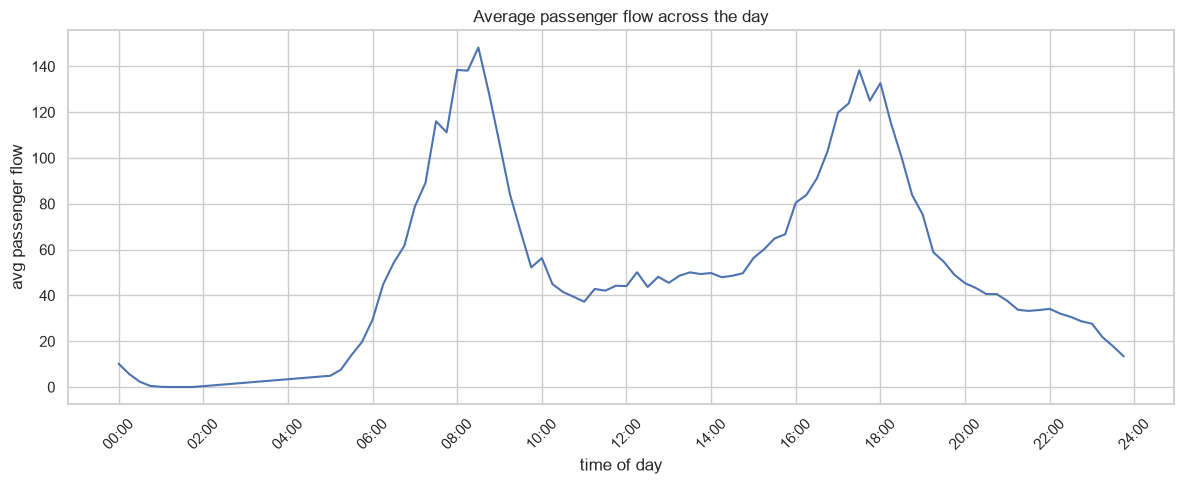

In [5]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=by_time, x="minutes", y="value")
plt.xticks(range(0, 24 * 60 + 1, 120), [f"{h:02d}:00" for h in range(0, 25, 2)], rotation=45)
plt.xlabel("time of day")
plt.ylabel("avg passenger flow")
plt.title("Average passenger flow across the day")
plt.tight_layout()


## Station and line rankings
Look at which stations and lines are consistently busiest.

In [6]:
station_rank = (crowding.groupby(["station_naptan", "common_name"])["value"]
                .mean().reset_index().sort_values("value", ascending=False))
station_rank.head(15)


,station_naptan,common_name,value
31,940GZZLUBXN,Brixton,625.130952
238,940GZZLUVXL,Vauxhall,371.595238
264,940GZZLUWWL,Walthamstow Central,350.309524
55,940GZZLUCYF,Canary Wharf,260.107143
168,940GZZLUOXC,Oxford Circus Underground Station,255.246032
194,940GZZLUSBC,Shepherd's Bush,230.297619
156,940GZZLUNGW,North Greenwich,227.833333
247,940GZZLUWIM,Wimbledon,226.309524
140,940GZZLUMDN,Morden Underground Station,195.166667
38,940GZZLUCHL,Chancery Lane Underground Station,192.678571


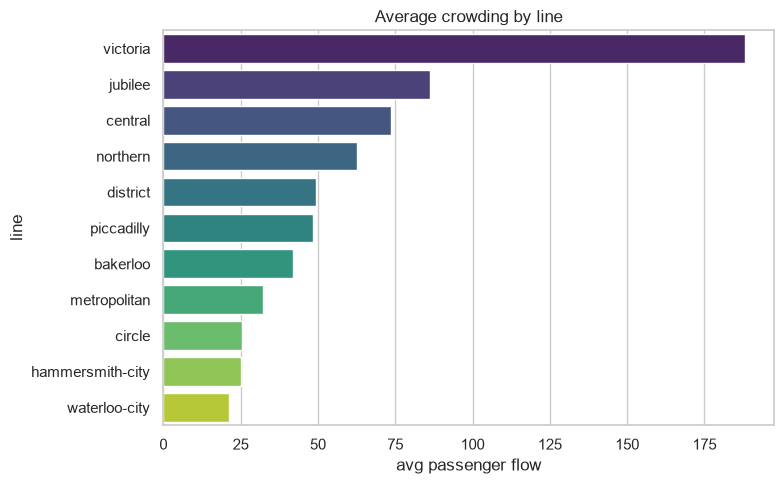

In [7]:
line_rank = crowding.groupby("line")["value"].mean().reset_index().sort_values("value", ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=line_rank, x="value", y="line", hue="line", palette="viridis", legend=False)
plt.xlabel("avg passenger flow")
plt.title("Average crowding by line")
plt.tight_layout()


## Line × hour heatmap
Where does each line get busy across the day? This shows the average flow for every line by hour.


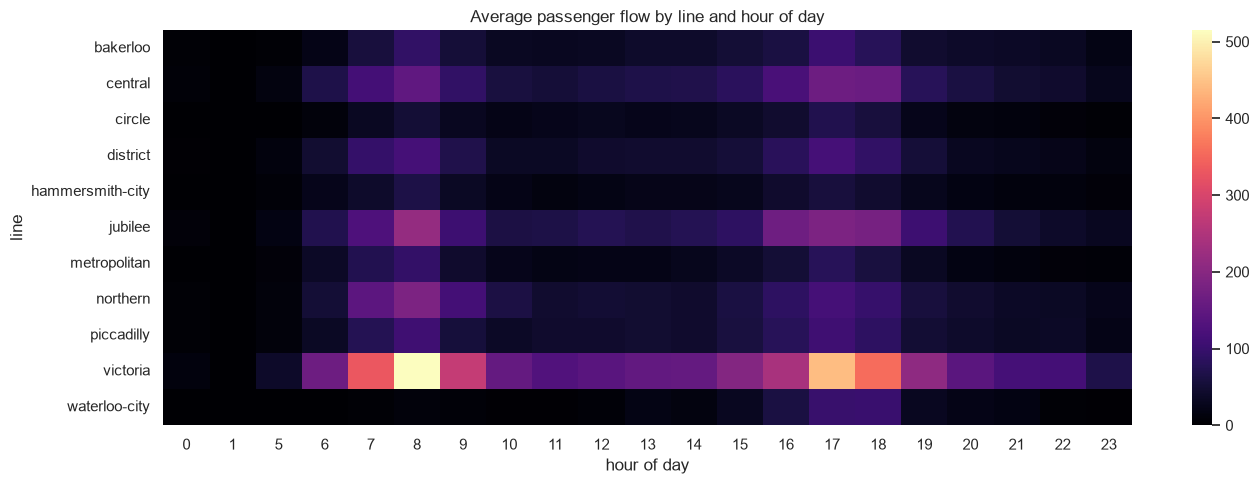

In [8]:
pivot = crowding.pivot_table(index="line", columns="hour", values="value", aggfunc="mean")
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap="magma")
plt.title("Average passenger flow by line and hour of day")
plt.xlabel("hour of day")
plt.ylabel("line")
plt.tight_layout()


## Spatial view — where the crowds are
Join station coordinates from the master table and map peak-hour crowding (AM 07–10 and PM 17–19) across London, using each station's longitude and latitude.

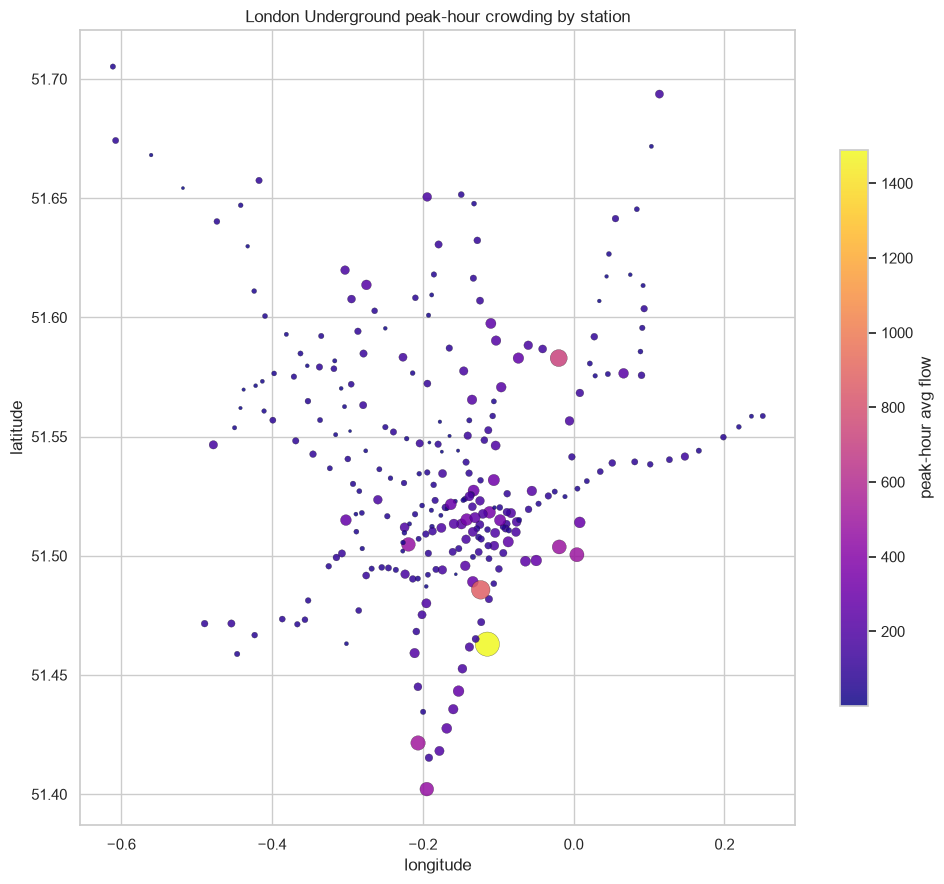

In [9]:
# peak-hour mean flow per station (AM 07:00-09:59 and PM 17:00-18:59)
peak_mask = crowding["hour"].between(7, 9) | crowding["hour"].between(17, 18)
station_peak = (crowding[peak_mask].groupby("station_naptan")["value"]
                .mean().rename("peak_flow"))

geo = stations.merge(station_peak, left_on="naptan", right_index=True, how="left")
geo = geo.dropna(subset=["lat", "lon", "peak_flow"])

fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(
    geo["lon"], geo["lat"],
    s=geo["peak_flow"] / geo["peak_flow"].max() * 300 + 5,
    c=geo["peak_flow"], cmap="plasma", alpha=0.85, edgecolor="k", linewidth=0.2,
)
plt.colorbar(sc, ax=ax, label="peak-hour avg flow", shrink=0.7)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("London Underground peak-hour crowding by station")
plt.tight_layout()

## Temporal flow — how the crowd moves through the day
Aggregate each station's average flow per hour and map it over time. This shows the
morning build-up in the centre, the commuter peaks, and the evening wind-down.


In [10]:
# mean flow per station and hour, joined to coordinates
coords = stations[["naptan", "name", "lat", "lon"]].rename(columns={"naptan": "station_naptan"})
station_hour = (crowding.groupby(["station_naptan", "hour"])["value"].mean()
                .reset_index()
                .merge(coords, on="station_naptan", how="left")
                .dropna(subset=["lat", "lon"]))

# shared colour/size scale so frames are comparable (98th pct clips extreme outliers)
vmax = station_hour["value"].quantile(0.98)
print("rows:", station_hour.shape[0], "| hours:", sorted(station_hour["hour"].unique()))
station_hour.head()

rows: 5607 | hours: [np.int64(0), np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,station_naptan,hour,value,name,lat,lon
0,940GZZLUACT,0,1.000,Acton Town,51.503057,-0.280462
1,940GZZLUACT,1,0.000,Acton Town,51.503057,-0.280462
2,940GZZLUACT,5,1.875,Acton Town,51.503057,-0.280462
3,940GZZLUACT,6,2.875,Acton Town,51.503057,-0.280462
4,940GZZLUACT,7,10.375,Acton Town,51.503057,-0.280462


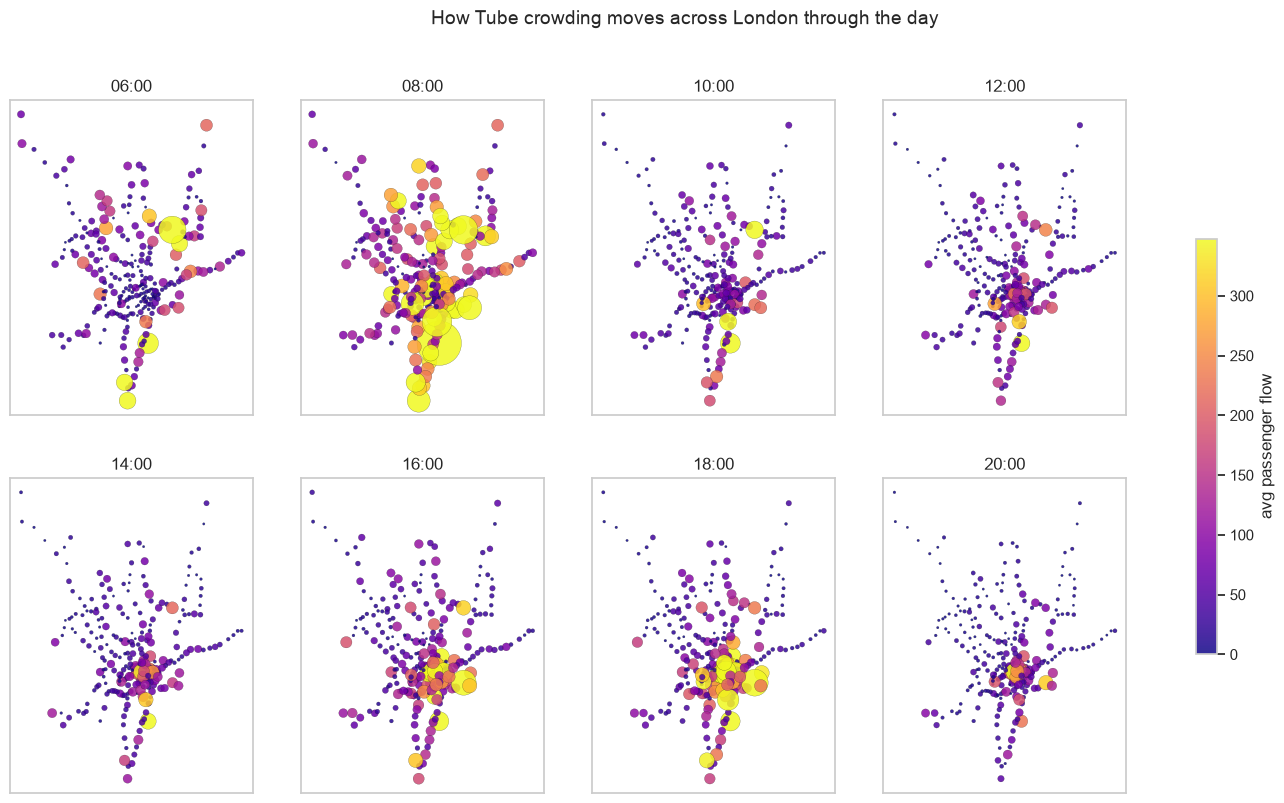

In [11]:
# small-multiples: the map at key hours across the day
show_hours = [6, 8, 10, 12, 14, 16, 18, 20]
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
for ax, h in zip(axes.ravel(), show_hours):
    d = station_hour[station_hour["hour"] == h]
    sc = ax.scatter(d["lon"], d["lat"], c=d["value"], cmap="plasma",
                    s=d["value"] / vmax * 120 + 3, vmin=0, vmax=vmax,
                    alpha=0.85, edgecolor="k", linewidth=0.15)
    ax.set_title(f"{h:02d}:00")
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, label="avg passenger flow", shrink=0.6)
fig.suptitle("How Tube crowding moves across London through the day", fontsize=14)
plt.show()

In [12]:
# animated map: crowding evolving hour by hour
from matplotlib import animation
from IPython.display import HTML

hours = sorted(station_hour["hour"].unique())
fig, ax = plt.subplots(figsize=(9, 9))
d0 = station_hour[station_hour["hour"] == hours[0]]
scat = ax.scatter(d0["lon"], d0["lat"], c=d0["value"], cmap="plasma",
                  s=d0["value"] / vmax * 250 + 3, vmin=0, vmax=vmax,
                  alpha=0.85, edgecolor="k", linewidth=0.2)
fig.colorbar(scat, ax=ax, label="avg passenger flow")
ax.set_xlim(station_hour["lon"].min() - 0.02, station_hour["lon"].max() + 0.02)
ax.set_ylim(station_hour["lat"].min() - 0.02, station_hour["lat"].max() + 0.02)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
title = ax.set_title("")

def update(h):
    d = station_hour[station_hour["hour"] == h]
    scat.set_offsets(d[["lon", "lat"]].to_numpy())
    scat.set_array(d["value"].to_numpy())
    scat.set_sizes(d["value"].to_numpy() / vmax * 250 + 3)
    title.set_text(f"Tube crowding at {h:02d}:00")
    return scat, title

anim = animation.FuncAnimation(fig, update, frames=hours, interval=600, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())